In [ ]:
!pip install understatapi pandas --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 537.7/537.7 kB 2.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.4/159.4 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.5/153.5 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.1/138.1 kB 8.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.
blobfile 3.2.0 requires urllib3>=2,

In [ ]:
import pandas as pd
import understatapi

client = understatapi.UnderstatClient()

league = client.league(league='EPL')
matches = league.get_match_data(season='2025')

df = pd.DataFrame(matches)

In [ ]:
shot_data = client.match(match='29139').get_shot_data()
shot_data

{'h': [{'id': '686575',
   'minute': '10',
   'result': 'MissedShots',
   'X': '0.7809999847412109',
   'Y': '0.6669999694824219',
   'xG': '0.018436796963214874',
   'player': 'Gabriel',
   'h_a': 'h',
   'player_id': '5613',
   'situation': 'SetPiece',
   'season': '2025',
   'shotType': 'LeftFoot',
   'match_id': '29139',
   'h_team': 'Arsenal',
   'a_team': 'Burnley',
   'h_goals': '1',
   'a_goals': '0',
   'date': '2026-05-18 19:00:00',
   'player_assisted': 'Riccardo Calafiori',
   'lastAction': 'BallTouch'},
  {'id': '686577',
   'minute': '12',
   'result': 'BlockedShot',
   'X': '0.8690000152587891',
   'Y': '0.33099998474121095',
   'xG': '0.05039796978235245',
   'player': 'Bukayo Saka',
   'h_a': 'h',
   'player_id': '7322',
   'situation': 'OpenPlay',
   'season': '2025',
   'shotType': 'LeftFoot',
   'match_id': '29139',
   'h_team': 'Arsenal',
   'a_team': 'Burnley',
   'h_goals': '1',
   'a_goals': '0',
   'date': '2026-05-18 19:00:00',
   'player_assisted': None,
   '

In [ ]:
type(shot_data)

dict

In [ ]:
shot_data.keys()

dict_keys(['h', 'a'])

In [ ]:
import pandas as pd

df = pd.DataFrame(shot_data['h'] + shot_data['a'])

df[['X','Y','xG','minute']] = df[['X','Y','xG','minute']].astype(float)

df.head()

,id,minute,result,X,Y,xG,player,h_a,player_id,situation,season,shotType,match_id,h_team,a_team,h_goals,a_goals,date,player_assisted,lastAction
0,686575,10.0,MissedShots,0.781,0.667,0.018437,Gabriel,h,5613,SetPiece,2025,LeftFoot,29139,Arsenal,Burnley,1,0,2026-05-18 19:00:00,Riccardo Calafiori,BallTouch
1,686577,12.0,BlockedShot,0.869,0.331,0.050398,Bukayo Saka,h,7322,OpenPlay,2025,LeftFoot,29139,Arsenal,Burnley,1,0,2026-05-18 19:00:00,None,None
2,686578,13.0,MissedShots,0.902,0.380,0.056986,Kai Havertz,h,5220,FromCorner,2025,LeftFoot,29139,Arsenal,Burnley,1,0,2026-05-18 19:00:00,Leandro Trossard,Pass
3,686579,14.0,ShotOnPost,0.788,0.568,0.036300,Leandro Trossard,h,7698,OpenPlay,2025,RightFoot,29139,Arsenal,Burnley,1,0,2026-05-18 19:00:00,Eberechi Eze,Pass
4,686581,28.0,SavedShot,0.815,0.542,0.059477,Eberechi Eze,h,8706,OpenPlay,2025,RightFoot,29139,Arsenal,Burnley,1,0,2026-05-18 19:00:00,Riccardo Calafiori,HeadPass


In [ ]:
df.to_csv("Arsenal_vs_Burnley.csv", index=False)

In [ ]:
from google.colab import files

files.download("Arsenal_vs_Burnley.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print(df.columns)

Index(['id', 'minute', 'result', 'X', 'Y', 'xG', 'player', 'h_a', 'player_id',
       'situation', 'season', 'shotType', 'match_id', 'h_team', 'a_team',
       'h_goals', 'a_goals', 'date', 'player_assisted', 'lastAction'],
      dtype='object')


In [ ]:
print(df[['X','Y']].head())

       X      Y
0  0.781  0.667
1  0.869  0.331
2  0.902  0.380
3  0.788  0.568
4  0.815  0.542


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               18 non-null     object 
 1   minute           18 non-null     float64
 2   result           18 non-null     object 
 3   X                18 non-null     float64
 4   Y                18 non-null     float64
 5   xG               18 non-null     float64
 6   player           18 non-null     object 
 7   h_a              18 non-null     object 
 8   player_id        18 non-null     object 
 9   situation        18 non-null     object 
 10  season           18 non-null     object 
 11  shotType         18 non-null     object 
 12  match_id         18 non-null     object 
 13  h_team           18 non-null     object 
 14  a_team           18 non-null     object 
 15  h_goals          18 non-null     object 
 16  a_goals          18 non-null     object 
 17  date             1

# Q1: Which team created higher-quality chances in the match?

In [ ]:
# Create a team column
df["team"] = df.apply(
    lambda row: row["h_team"] if row["h_a"] == "h" else row["a_team"],
    axis=1
)

# Total xG per team
team_xg = df.groupby("team")["xG"].sum().sort_values(ascending=False)

print(team_xg)

team
Arsenal    1.226954
Burnley    0.194884
Name: xG, dtype: float64


# Total xG

In [ ]:
df.groupby("team")["xG"].sum()

,xG
team,
Arsenal,1.226954
Burnley,0.194884


# Number of Shots

In [ ]:
df.groupby("team")["id"].count()

,id
team,
Arsenal,13
Burnley,5


# Average xG per Shot

In [ ]:
df.groupby("team")["xG"].mean()

,xG
team,
Arsenal,0.094381
Burnley,0.038977


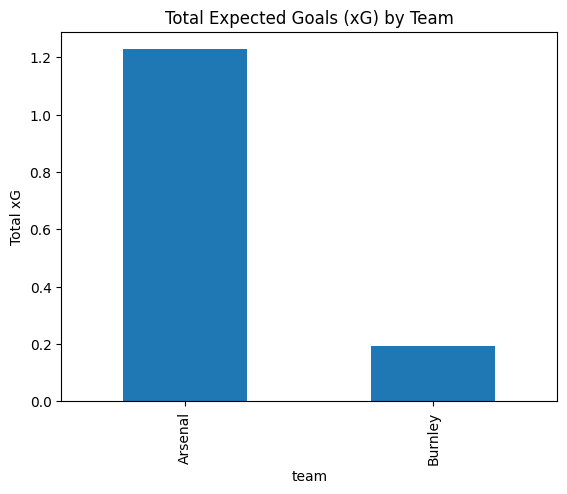

In [ ]:
import matplotlib.pyplot as plt

team_xg.plot(kind="bar")
plt.title("Total Expected Goals (xG) by Team")
plt.ylabel("Total xG")
plt.show()

# Q2: Which players were most efficient in chance conversion?

In [ ]:
import numpy as np

# Create goal column (1 if goal, 0 otherwise)
df["goal"] = df["result"].apply(lambda x: 1 if x == "Goal" else 0)

# Aggregate by player
player_perf = df.groupby("player").agg(
    shots=("id", "count"),
    xG=("xG", "sum"),
    goals=("goal", "sum")
)

# Efficiency metric
player_perf["xG_diff"] = player_perf["goals"] - player_perf["xG"]
player_perf["conversion_rate"] = player_perf["goals"] / player_perf["shots"]

# Sort by efficiency
player_perf = player_perf.sort_values("xG_diff", ascending=False)

player_perf

,shots,xG,goals,xG_diff,conversion_rate
player,,,,,
Kai Havertz,3,0.616793,1,0.383207,0.333333
Jaidon Anthony,1,0.016024,0,-0.016024,0.000000
Gabriel,1,0.018437,0,-0.018437,0.000000
Florentino Luís,1,0.036573,0,-0.036573,0.000000
Loum Tchaouna,1,0.049781,0,-0.049781,0.000000
Leandro Trossard,2,0.090598,0,-0.090598,0.000000
Hannibal Mejbri,2,0.092506,0,-0.092506,0.000000
Martin Odegaard,1,0.097594,0,-0.097594,0.000000
Bukayo Saka,3,0.162649,0,-0.162649,0.000000


# From which game situations were most dangerous chances created?

# Aggregate xG by Situation

In [ ]:
situation_xg = df.groupby("situation").agg(
    total_xG=("xG", "sum"),
    shots=("id", "count")
).sort_values("total_xG", ascending=False)

situation_xg

,total_xG,shots
situation,,
OpenPlay,0.756392,13
FromCorner,0.592711,3
SetPiece,0.072734,2


In [ ]:
situation_xg["xG_per_shot"] = situation_xg["total_xG"] / situation_xg["shots"]
situation_xg

,total_xG,shots,xG_per_shot
situation,,,
OpenPlay,0.756392,13,0.058184
FromCorner,0.592711,3,0.197570
SetPiece,0.072734,2,0.036367


In [ ]:
team_situation = df.groupby(["team", "situation"]).agg(
    total_xG=("xG", "sum"),
    shots=("id", "count")
).reset_index()

team_situation.sort_values(["team", "total_xG"], ascending=[True, False])

,team,situation,total_xG,shots
1,Arsenal,OpenPlay,0.598081,9
0,Arsenal,FromCorner,0.556138,2
2,Arsenal,SetPiece,0.072734,2
4,Burnley,OpenPlay,0.158311,4
3,Burnley,FromCorner,0.036573,1


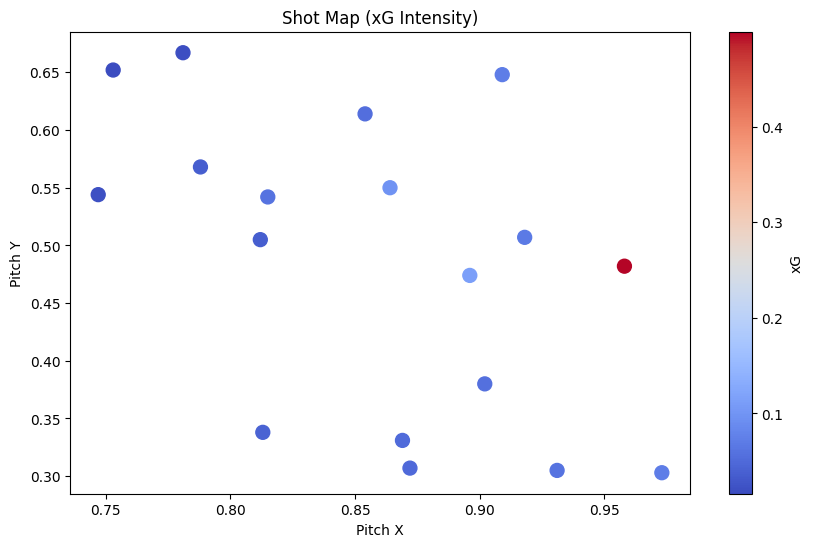

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(df["X"], df["Y"], c=df["xG"], cmap="coolwarm", s=100)

plt.title("Shot Map (xG Intensity)")
plt.xlabel("Pitch X")
plt.ylabel("Pitch Y")
plt.colorbar(label="xG")

plt.show()

In [ ]:
player_situation = df.groupby(["team","player", "situation","result"]).agg(
    total_xG=("xG", "sum"),
    shots=("id", "count")
).reset_index()

player_situation.sort_values("total_xG", ascending=False)

,team,player,situation,result,total_xG,shots
5,Arsenal,Kai Havertz,FromCorner,Goal,0.499152,1
2,Arsenal,Eberechi Eze,OpenPlay,SavedShot,0.127739,2
3,Arsenal,Eberechi Eze,OpenPlay,ShotOnPost,0.113144,1
1,Arsenal,Bukayo Saka,OpenPlay,MissedShots,0.112251,2
10,Arsenal,Martin Odegaard,OpenPlay,BlockedShot,0.097594,1
12,Burnley,Hannibal Mejbri,OpenPlay,MissedShots,0.092506,2
7,Arsenal,Kai Havertz,OpenPlay,BlockedShot,0.060654,1
6,Arsenal,Kai Havertz,FromCorner,MissedShots,0.056986,1
9,Arsenal,Leandro Trossard,SetPiece,MissedShots,0.054298,1
0,Arsenal,Bukayo Saka,OpenPlay,BlockedShot,0.050398,1


# Q4: What types of shots generated the highest expected value?

In [ ]:
shottype_xg = df.groupby("shotType").agg(
    total_xG=("xG", "sum"),
    shots=("id", "count")
).sort_values("total_xG", ascending=False)

shottype_xg

,total_xG,shots
shotType,,
Head,0.567413,2
RightFoot,0.428432,8
LeftFoot,0.425992,8


In [ ]:
shottype_xg["xG_per_shot"] = shottype_xg["total_xG"] / shottype_xg["shots"]
shottype_xg

,total_xG,shots,xG_per_shot
shotType,,,
Head,0.567413,2,0.283707
RightFoot,0.428432,8,0.053554
LeftFoot,0.425992,8,0.053249


# Q5: Where on the pitch were the most dangerous shots taken?

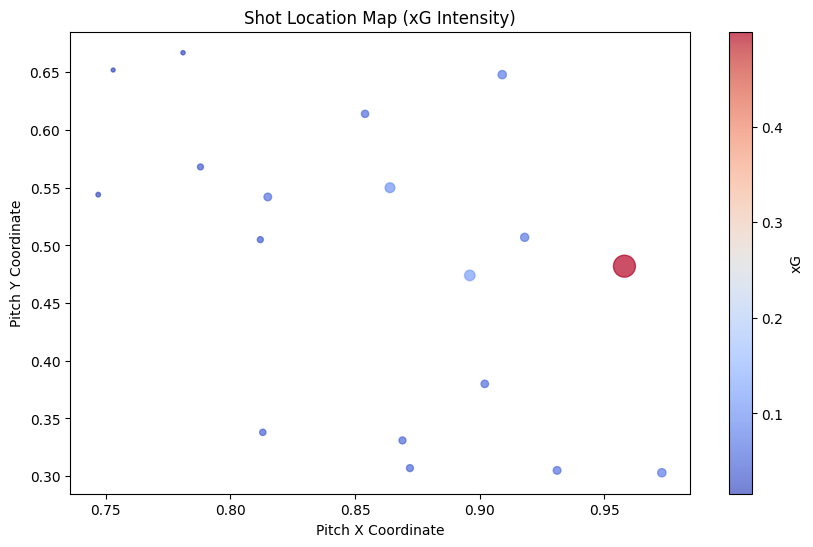

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    df["X"],
    df["Y"],
    c=df["xG"],
    s=df["xG"] * 500,
    cmap="coolwarm",
    alpha=0.7
)

plt.title("Shot Location Map (xG Intensity)")
plt.xlabel("Pitch X Coordinate")
plt.ylabel("Pitch Y Coordinate")

plt.colorbar(label="xG")

plt.show()

In [ ]:
shots_counts= df.groupby(["team","player", "X","Y","xG"])["result"].value_counts().reset_index(name="shots")
print(shots_counts)

       team            player      X      Y        xG       result  shots
0   Arsenal       Bukayo Saka  0.813  0.338  0.040854  MissedShots      1
1   Arsenal       Bukayo Saka  0.869  0.331  0.050398  BlockedShot      1
2   Arsenal       Bukayo Saka  0.973  0.303  0.071398  MissedShots      1
3   Arsenal      Eberechi Eze  0.815  0.542  0.059477    SavedShot      1
4   Arsenal      Eberechi Eze  0.896  0.474  0.113144   ShotOnPost      1
5   Arsenal      Eberechi Eze  0.918  0.507  0.068261    SavedShot      1
6   Arsenal           Gabriel  0.781  0.667  0.018437  MissedShots      1
7   Arsenal       Kai Havertz  0.902  0.380  0.056986  MissedShots      1
8   Arsenal       Kai Havertz  0.931  0.305  0.060654  BlockedShot      1
9   Arsenal       Kai Havertz  0.958  0.482  0.499152         Goal      1
10  Arsenal  Leandro Trossard  0.788  0.568  0.036300   ShotOnPost      1
11  Arsenal  Leandro Trossard  0.854  0.614  0.054298  MissedShots      1
12  Arsenal   Martin Odegaard  0.864  

In [ ]:
shots_counts= df.groupby(["team","player", "X","Y","xG","situation"])["result"].value_counts().reset_index(name="shots")
print(shots_counts)

       team            player      X      Y        xG   situation  \
0   Arsenal       Bukayo Saka  0.813  0.338  0.040854    OpenPlay   
1   Arsenal       Bukayo Saka  0.869  0.331  0.050398    OpenPlay   
2   Arsenal       Bukayo Saka  0.973  0.303  0.071398    OpenPlay   
3   Arsenal      Eberechi Eze  0.815  0.542  0.059477    OpenPlay   
4   Arsenal      Eberechi Eze  0.896  0.474  0.113144    OpenPlay   
5   Arsenal      Eberechi Eze  0.918  0.507  0.068261    OpenPlay   
6   Arsenal           Gabriel  0.781  0.667  0.018437    SetPiece   
7   Arsenal       Kai Havertz  0.902  0.380  0.056986  FromCorner   
8   Arsenal       Kai Havertz  0.931  0.305  0.060654    OpenPlay   
9   Arsenal       Kai Havertz  0.958  0.482  0.499152  FromCorner   
10  Arsenal  Leandro Trossard  0.788  0.568  0.036300    OpenPlay   
11  Arsenal  Leandro Trossard  0.854  0.614  0.054298    SetPiece   
12  Arsenal   Martin Odegaard  0.864  0.550  0.097594    OpenPlay   
13  Burnley   Florentino Luís  0.8

In [ ]:
pip install mplsoccer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 1.2 MB/s eta 0:00:00


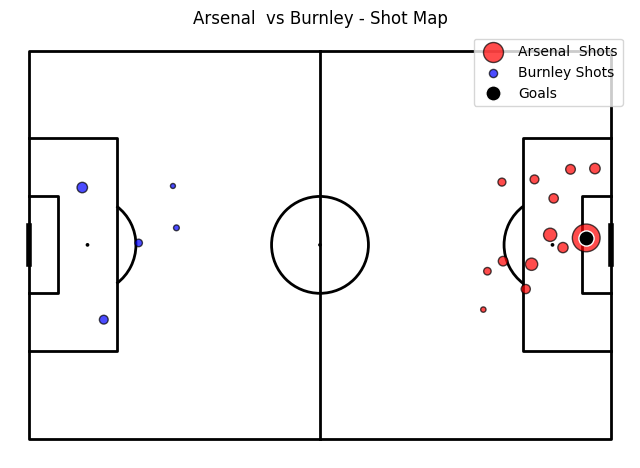

In [ ]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt

# -----------------------------
# Pitch setup
# -----------------------------
pitch = Pitch(pitch_type='statsbomb', pitch_color='white', line_color='black')
fig, ax = plt.subplots(figsize=(8, 6))
pitch.draw(ax=ax)

# -----------------------------
# Convert coordinates
# -----------------------------
df['x'] = df['X'] * 120
df['y'] = df['Y'] * 80

# -----------------------------
# Split teams (IMPORTANT: use .copy())
# -----------------------------
home = df[df['h_a'] == 'h'].copy()
away = df[df['h_a'] == 'a'].copy()

# -----------------------------
# Flip away team coordinates (attacking direction fix)
# -----------------------------
away['x'] = 120 - away['x']
away['y'] = 80 - away['y']

# -----------------------------
# Plot shots by team
# -----------------------------
for d, color, label in [
    (home, 'red', 'Arsenal  Shots'),
    (away, 'blue', 'Burnley Shots')
]:
    ax.scatter(
        d['x'], d['y'],
        s=d['xG'] * 800,
        alpha=0.7,
        c=color,
        edgecolors='black',
        label=label
    )

# -----------------------------
# Highlight goals
# -----------------------------
goals = df[df['result'] == 'Goal'].copy()

# Apply same flip logic for away goals
goals.loc[goals['h_a'] == 'a', 'x'] = 120 - goals.loc[goals['h_a'] == 'a', 'x']
goals.loc[goals['h_a'] == 'a', 'y'] = 80 - goals.loc[goals['h_a'] == 'a', 'y']

ax.scatter(
    goals['x'], goals['y'],
    c='black',
    s=120,
    edgecolors='white',
    label='Goals',
    zorder=3
)

# -----------------------------
# Title + legend
# -----------------------------
plt.title("Arsenal  vs Burnley - Shot Map", fontsize=12)
plt.legend()
plt.show()

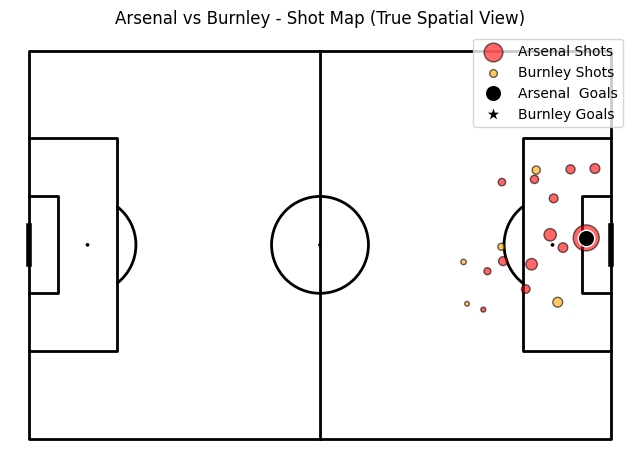

In [ ]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt

pitch = Pitch(pitch_type='statsbomb', pitch_color='white', line_color='black')
fig, ax = plt.subplots(figsize=(8, 6))
pitch.draw(ax=ax)

# -----------------------------
# Convert coordinates
# -----------------------------
df = df.copy()
df['x'] = df['X'] * 120
df['y'] = df['Y'] * 80

# -----------------------------
# Split teams safely
# -----------------------------
home = df[df['h_a'] == 'h'].copy()
away = df[df['h_a'] == 'a'].copy()

# -----------------------------
# Plot home team
# -----------------------------
ax.scatter(
    home['x'], home['y'],
    s=home['xG'] * 700,
    c='red',
    alpha=0.6,
    edgecolors='black',
    label='Arsenal Shots'
)

# -----------------------------
# Plot away team
# -----------------------------
ax.scatter(
    away['x'], away['y'],
    s=away['xG'] * 700,
    c='orange',
    alpha=0.6,
    edgecolors='black',
    label='Burnley Shots'
)

# -----------------------------
# Goals (kept team-aware)
# -----------------------------
home_goals = home[home['result'] == 'Goal']
away_goals = away[away['result'] == 'Goal']

ax.scatter(
    home_goals['x'], home_goals['y'],
    c='black',
    s=140,
    edgecolors='white',
    zorder=3,
    label='Arsenal  Goals'
)

ax.scatter(
    away_goals['x'], away_goals['y'],
    c='black',
    s=140,
    edgecolors='white',
    marker='*',
    zorder=3,
    label='Burnley Goals'
)

# -----------------------------
# Title + legend
# -----------------------------
plt.title("Arsenal vs Burnley - Shot Map (True Spatial View)", fontsize=12)
plt.legend()
plt.show()

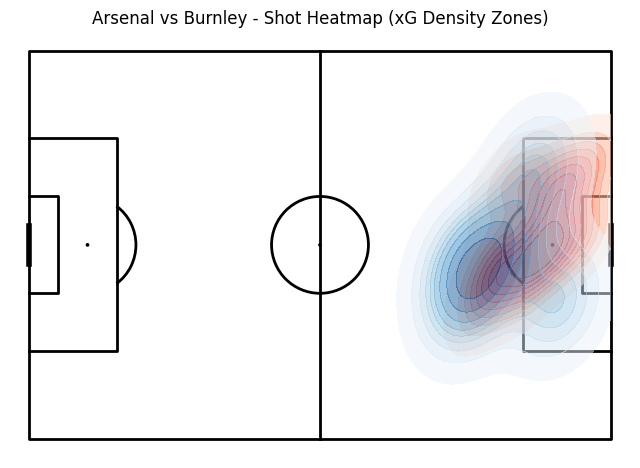

In [ ]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt

# -----------------------------
# Pitch
# -----------------------------
pitch = Pitch(pitch_type='statsbomb', pitch_color='white', line_color='black')
fig, ax = plt.subplots(figsize=(8, 6))
pitch.draw(ax=ax)

# -----------------------------
# Prepare data
# -----------------------------
df = df.copy()
df['x'] = df['X'] * 120
df['y'] = df['Y'] * 80

home = df[df['h_a'] == 'h']
away = df[df['h_a'] == 'a']

# -----------------------------
# Heatmap: Home team
# -----------------------------
pitch.kdeplot(
    home['x'],
    home['y'],
    ax=ax,
    fill=True,
    cmap='Reds',
    alpha=0.6,
    label='Home Heatmap'
)

# -----------------------------
# Heatmap: Away team
# -----------------------------
pitch.kdeplot(
    away['x'],
    away['y'],
    ax=ax,
    fill=True,
    cmap='Blues',
    alpha=0.5,
    label='Away Heatmap'
)

# -----------------------------
# Title
# -----------------------------
plt.title("Arsenal vs Burnley - Shot Heatmap (xG Density Zones)")
plt.show()

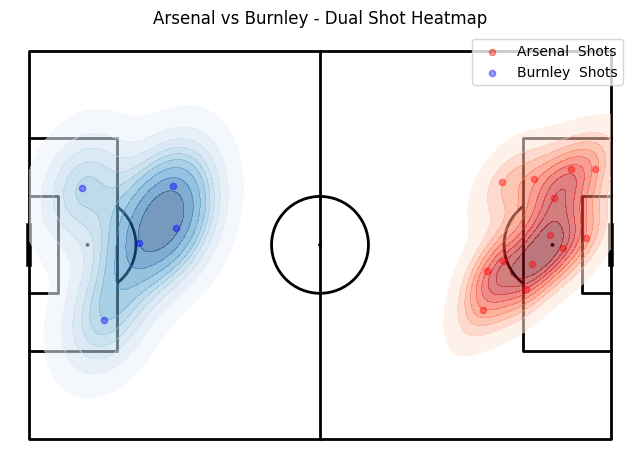

In [ ]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt

# -----------------------------
# Pitch
# -----------------------------
pitch = Pitch(pitch_type='statsbomb', pitch_color='white', line_color='black')
fig, ax = plt.subplots(figsize=(8, 6))
pitch.draw(ax=ax)

# -----------------------------
# Prepare data
# -----------------------------
df = df.copy()
df['x'] = df['X'] * 120
df['y'] = df['Y'] * 80

home = df[df['h_a'] == 'h'].copy()
away = df[df['h_a'] == 'a'].copy()

# -----------------------------
# Flip ONLY away team (so both attack same direction visually)
# -----------------------------
away['x'] = 120 - away['x']
away['y'] = 80 - away['y']

# -----------------------------
# Combine for heatmaps per team
# -----------------------------
pitch.kdeplot(
    home['x'],
    home['y'],
    ax=ax,
    fill=True,
    cmap='Reds',
    alpha=0.55
)

pitch.kdeplot(
    away['x'],
    away['y'],
    ax=ax,
    fill=True,
    cmap='Blues',
    alpha=0.55
)

# -----------------------------
# Optional: overlay shot points (for clarity)
# -----------------------------
ax.scatter(home['x'], home['y'], c='red', s=20, alpha=0.4, label='Arsenal  Shots')
ax.scatter(away['x'], away['y'], c='blue', s=20, alpha=0.4, label='Burnley  Shots')

# -----------------------------
# Title + legend
# -----------------------------
plt.title("Arsenal vs Burnley - Dual Shot Heatmap")
plt.legend()
plt.show()

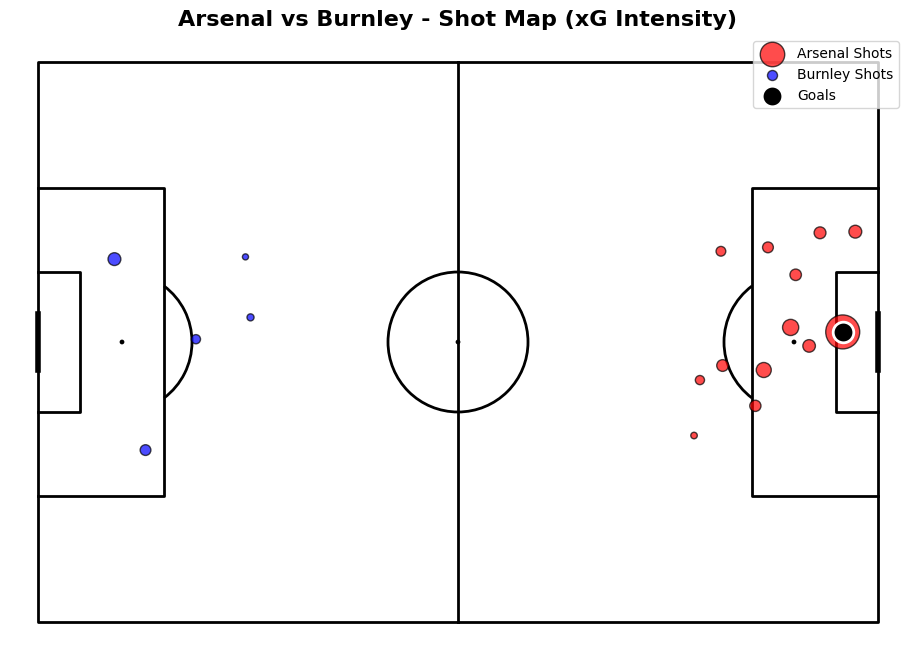

In [ ]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt

# -----------------------------
# COPY DATA
# -----------------------------
df = df.copy()

# -----------------------------
# CONVERT UNDERSTAT COORDINATES
# -----------------------------
df['x'] = df['X'] * 120
df['y'] = df['Y'] * 80

# -----------------------------
# SPLIT TEAMS
# -----------------------------
home = df[df['h_a'] == 'h'].copy()
away = df[df['h_a'] == 'a'].copy()

# -----------------------------
# FLIP AWAY TEAM
# IMPORTANT
# -----------------------------
away['x'] = 120 - away['x']
away['y'] = 80 - away['y']

# -----------------------------
# TEAM NAMES
# -----------------------------
home_team = df['h_team'].iloc[0]
away_team = df['a_team'].iloc[0]

# -----------------------------
# CREATE PITCH
# -----------------------------
pitch = Pitch(
    pitch_type='statsbomb',
    pitch_color='white',
    line_color='black'
)

fig, ax = plt.subplots(figsize=(12, 8))
pitch.draw(ax=ax)

# -----------------------------
# HOME SHOTS
# -----------------------------
ax.scatter(
    home['x'],
    home['y'],
    s=home['xG'] * 1200,
    color='red',
    edgecolors='black',
    alpha=0.7,
    label=f'{home_team} Shots'
)

# -----------------------------
# AWAY SHOTS
# -----------------------------
ax.scatter(
    away['x'],
    away['y'],
    s=away['xG'] * 1200,
    color='blue',
    edgecolors='black',
    alpha=0.7,
    label=f'{away_team} Shots'
)

# -----------------------------
# GOALS
# -----------------------------
goals = df[df['result'] == 'Goal'].copy()

# Flip away goals too
away_goals = goals[goals['h_a'] == 'a'].copy()
away_goals['x'] = 120 - (away_goals['X'] * 120)
away_goals['y'] = 80 - (away_goals['Y'] * 80)

home_goals = goals[goals['h_a'] == 'h'].copy()
home_goals['x'] = home_goals['X'] * 120
home_goals['y'] = home_goals['Y'] * 80

goal_plot = pd.concat([home_goals, away_goals])

ax.scatter(
    goal_plot['x'],
    goal_plot['y'],
    s=220,
    color='black',
    edgecolors='white',
    linewidth=2,
    zorder=5,
    label='Goals'
)

# -----------------------------
# TITLE
# -----------------------------
plt.title(
    f'{home_team} vs {away_team} - Shot Map (xG Intensity)',
    fontsize=16,
    fontweight='bold'
)

plt.legend()
plt.show()

In [ ]:
plt.savefig("shot_map.png", dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [ ]:
files.download("shot_map.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

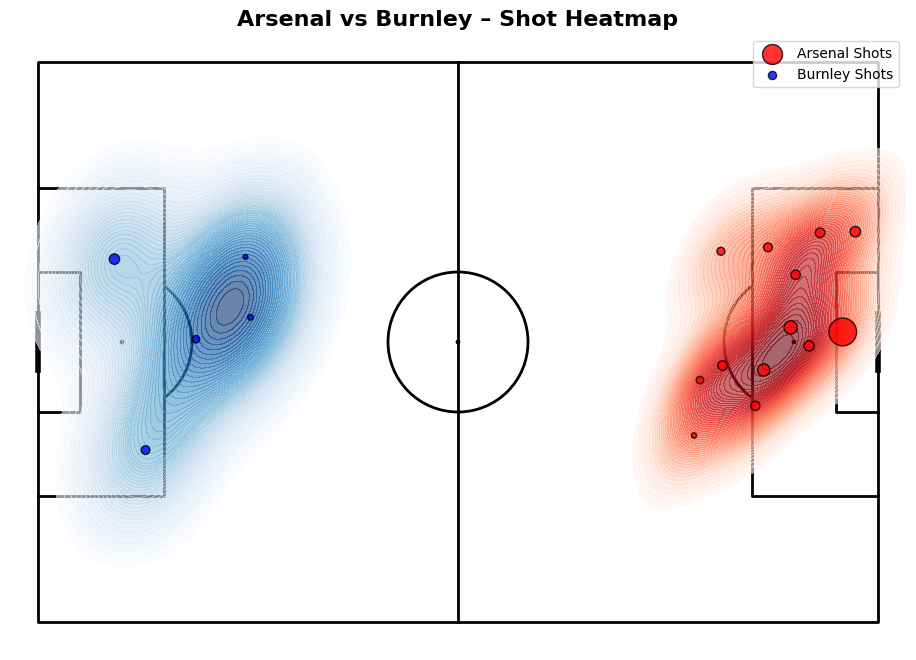

In [ ]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# -----------------------------
# COPY DATA
# -----------------------------
df = df.copy()

# -----------------------------
# CONVERT UNDERSTAT COORDINATES
# -----------------------------
df['x'] = df['X'] * 120
df['y'] = df['Y'] * 80

# -----------------------------
# SPLIT TEAMS
# -----------------------------
home = df[df['h_a'] == 'h'].copy()
away = df[df['h_a'] == 'a'].copy()

# -----------------------------
# FLIP AWAY TEAM
# -----------------------------
away['x'] = 120 - away['x']
away['y'] = 80 - away['y']

# -----------------------------
# TEAM NAMES
# -----------------------------
home_team = df['h_team'].iloc[0]
away_team = df['a_team'].iloc[0]

# -----------------------------
# CREATE PITCH
# -----------------------------
pitch = Pitch(
    pitch_type='statsbomb',
    pitch_color='white',
    line_color='black',
    linewidth=2
)

fig, ax = plt.subplots(figsize=(12, 8))
pitch.draw(ax=ax)

# -----------------------------
# HOME TEAM HEATMAP
# -----------------------------
sns.kdeplot(
    x=home['x'],
    y=home['y'],
    fill=True,
    cmap='Reds',
    alpha=0.6,
    levels=50,
    thresh=0.05,
    ax=ax
)

# -----------------------------
# AWAY TEAM HEATMAP
# -----------------------------
sns.kdeplot(
    x=away['x'],
    y=away['y'],
    fill=True,
    cmap='Blues',
    alpha=0.6,
    levels=50,
    thresh=0.05,
    ax=ax
)

# -----------------------------
# OPTIONAL: ADD SHOT POINTS
# -----------------------------
ax.scatter(
    home['x'],
    home['y'],
    s=home['xG'] * 800,
    color='red',
    edgecolors='black',
    alpha=0.8,
    label=f'{home_team} Shots'
)

ax.scatter(
    away['x'],
    away['y'],
    s=away['xG'] * 800,
    color='blue',
    edgecolors='black',
    alpha=0.8,
    label=f'{away_team} Shots'
)

# -----------------------------
# TITLE
# -----------------------------
plt.title(
    f'{home_team} vs {away_team} – Shot Heatmap',
    fontsize=16,
    fontweight='bold'
)

plt.legend(loc='upper right')
plt.show()

In [ ]:
plt.savefig("heat_map.png", dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [ ]:
files.download("heat_map.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>